# SARIMAX Modeling

The Neural Prophet library is not being updated. There are known issues in using Neural Prophet with newer versions of numpy. The only goal of this notebook is to try and develop a SARIMAX model instead for short term forecasting.

Our goal so far has been for 14 day forecasts, but heere, we might eve aim to do 7 day forecasts instead.

**Warning:** As wrriten, there seems to be a bug which is causing there to be very negative valued forecasts!

## Import Packages

In [9]:
import requests 
import os
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

from pandas.tseries.holiday import USFederalHolidayCalendar
import itertools
import optuna
import logging

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pandas.tseries.holiday import USFederalHolidayCalendar


## Import Data

In [10]:
rat_sighting = pd.read_csv("../../scr/data/rat_sightings_data/Rat_Sightings_NYC.csv")
rat_sighting.columns = [t.partition('(')[0].strip().lower().replace(' ', '_') for t in rat_sighting.columns] #apply to column headers
rat_sighting['location_type'] = rat_sighting['location_type'].str.strip().str.replace(' ', '_').str.lower()  #apply to location_type column
cols_to_drop = [c for c in rat_sighting.columns if (rat_sighting[c].nunique(dropna=False) == 1)]
rat_sighting = rat_sighting.drop(columns=cols_to_drop)
rat_sighting['created_date'] = pd.to_datetime(rat_sighting['created_date']) 
rat_sighting = rat_sighting.drop(columns='park_borough')
rat_sighting = rat_sighting.drop(columns=['location'])
rs = rat_sighting.copy()
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

# lat, lon = 40.7831, -73.9712
# last_date = rs['ds'].max()
# start = "2020-01-01"
# end   = last_date.strftime("%Y-%m-%d")  # use last date of rs

# url = (
#     "https://archive-api.open-meteo.com/v1/archive"
#     f"?latitude={lat}&longitude={lon}"
#     f"&start_date={start}&end_date={end}"
#     "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
#     "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
#     "precipitation_sum,snowfall_sum"
#     "&timezone=America/New_York"
# )

# response = requests.get(url)
# data = response.json()

# if 'error' in data:
#     nd = pd.read_csv("weatherdata.csv")
#     nd['ds'] = pd.to_datetime(nd['date'])
#     wd = nd.drop(columns=['date'])
# else:
#     wd = pd.DataFrame(data["daily"])
#     wd["ds"] = pd.to_datetime(wd["time"])
#     wd = wd.drop(columns=["time"])

# wd = wd.reset_index(drop=True)
# future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),
#                              periods=14,
#                              freq='D')

# last_row = wd.iloc[-1]
# wd_14 = pd.DataFrame([last_row.values] * 14, columns=wd.columns)
# wd_14['ds'] = future_dates 
# wd_14 = wd_14.reset_index(drop=True)

# regressed_features = ['apparent_temperature_max', 'apparent_temperature_min', 'snowfall_sum']

# wd["ds"] = pd.to_datetime(wd["ds"])
# wd_14["ds"] = pd.to_datetime(wd_14["ds"])

# rs["ds"] = pd.to_datetime(rs["ds"])

# rs = rs.merge(wd[['ds'] + regressed_features], on="ds", how="left")

rs

/var/folders/ry/m6r2ndwd10bdv8tvww5hr2680000gn/T/ipykernel_12272/252888638.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rat_sighting['created_date'] = pd.to_datetime(rat_sighting['created_date'])


,ds,y
0,2020-01-01,17
1,2020-01-02,40
2,2020-01-03,41
3,2020-01-04,25
4,2020-01-05,17
...,...,...
2254,2026-03-04,45
2255,2026-03-05,55
2256,2026-03-06,47
2257,2026-03-07,39


## Tune Hyperparameters and Cross Validate to Check

In [ ]:
import pandas as pd
import numpy as np
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pandas.tseries.holiday import USFederalHolidayCalendar
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

regressed_features = ['apparent_temperature_max', 'apparent_temperature_min', 'snowfall_sum']

tscv_splits = 3
tscv_test_size = 7


fourier_K = 3 # number of Fourier terms
yearly_period = 365.25 # accounts for leap years
weekly_seasonality = 7 # as a reminder we are using weekly seasonality




cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=rs['ds'].min(), end=rs['ds'].max())
rs['holiday'] = rs['ds'].isin(holidays).astype(int)

def fourier_series(dates, period, K):
    t = np.arange(len(dates))
    return np.column_stack([func(2 * np.pi * k * t / period)
                            for k in range(1, K+1)
                            for func in (np.sin, np.cos)])

fourier_terms = fourier_series(rs['ds'], yearly_period, fourier_K)
fourier_df = pd.DataFrame(fourier_terms, columns=[f'fourier_{i}' for i in range(fourier_terms.shape[1])])

orders = (2,1,1)
seasonal_orders = (1,0,1,7)

exog = pd.concat([fourier_df, rs[['holiday'] + regressed_features].reset_index(drop=True)], axis=1)



stepwise_model = auto_arima(
    rs['y'],
    exogenous=exog,
    seasonal=True,
    m=weekly_seasonality,  # weekly seasonality
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action='ignore',
    # n_jobs=-1  # use all available CPU cores, but we must turn stepwise off. this might end up slower if you turn off stepwise
)
print("Auto ARIMA selected orders:", stepwise_model.order, stepwise_model.seasonal_order)



tscv = TimeSeriesSplit(n_splits=tscv_splits, test_size=tscv_test_size)
rmse_list = []
mape_list = []

for train_idx, test_idx in tscv.split(rs):
    y_train, y_test = rs['y'].iloc[train_idx], rs['y'].iloc[test_idx]
    exog_train, exog_test = exog.iloc[train_idx], exog.iloc[test_idx]
    
    model = SARIMAX(
        y_train,
        exog=exog_train,
        order=stepwise_model.order,
        seasonal_order=stepwise_model.seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
    
    pred = model.get_forecast(steps=len(y_test), exog=exog_test).predicted_mean
    
    rmse_list.append(np.sqrt(mean_squared_error(y_test, pred)))
    mape_list.append(mean_absolute_percentage_error(y_test, pred))

print(f"CV Results -> Avg RMSE: {np.mean(rmse_list):.2f}, Avg MAPE: {np.mean(mape_list)*100:.2f}%")

KeyError: "['apparent_temperature_max', 'apparent_temperature_min', 'snowfall_sum'] not in index"

Auto ARIMA selected orders: (2, 1, 1) (1, 0, 1, 7).

In [ ]:
exog

## Make the Final Model and Forecast

In [ ]:
regressed_features = ['apparent_temperature_max', 'apparent_temperature_min', 'snowfall_sum']

fourier_K = 5

yearly_period = 365.25

weekly_seasonality = 7

forecast_horizon = 7 


order = (2, 1, 1) 
seasonal_order = (1, 0, 1, 7)  

cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=rs['ds'].min(), end=rs['ds'].max())
rs['holiday'] = rs['ds'].isin(holidays).astype(int)

def fourier_series(dates, period, K):
    t = np.arange(len(dates))
    return np.column_stack([func(2 * np.pi * k * t / period)
                            for k in range(1, K+1)
                            for func in (np.sin, np.cos)])

fourier_terms = fourier_series(rs['ds'], yearly_period, fourier_K)
fourier_df = pd.DataFrame(fourier_terms, columns=[f'fourier_{i}' for i in range(fourier_terms.shape[1])])

exog = pd.concat([fourier_df, rs[['holiday'] + regressed_features].reset_index(drop=True)], axis=1)
sarimax_model = SARIMAX(
    rs['y'],
    exog=exog,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

last_date = rs['ds'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_horizon, freq='D')

last_row = rs.iloc[-1]
future_exog_df = pd.DataFrame([last_row[regressed_features + ['holiday']].values] * forecast_horizon,
                              columns=regressed_features + ['holiday'])
future_exog_df['holiday'] = future_dates.isin(holidays).astype(int)  # update holidays

future_fourier = fourier_series(future_dates, yearly_period, fourier_K)
future_fourier_df = pd.DataFrame(future_fourier, columns=fourier_df.columns)

future_exog = pd.concat([future_fourier_df.reset_index(drop=True), future_exog_df.reset_index(drop=True)], axis=1)




forecast = sarimax_model.get_forecast(steps=forecast_horizon, exog=future_exog)
forecast_values = forecast.predicted_mean
forecast_ci = forecast.conf_int()
forecast_df = pd.DataFrame({
    'ds': future_dates,
    'forecast': forecast_values,
    'lower_ci': forecast_ci.iloc[:, 0],
    'upper_ci': forecast_ci.iloc[:, 1]
})

print(forecast_df)

In [ ]:
fitted_values = sarimax_model.fittedvalues 

plt.figure(figsize=(20,6))
plt.plot(rs['ds'], rs['y'], label='Actuals', color='black', marker = 'o', linestyle='')
plt.plot(rs['ds'], fitted_values, label='Fitted (SARIMAX)', color='blue', alpha= 0.75)
plt.plot(forecast_df['ds'], forecast_df['forecast'], label='14-Day Forecast', color='red')

plt.fill_between(forecast_df['ds'], 
                 forecast_df['lower_ci'], 
                 forecast_df['upper_ci'], 
                 color='red', alpha=0.2, label='Forecast 95% CI')

plt.xlabel('Date')
plt.ylabel('y')
plt.title('SARIMAX Model: Actuals, Fitted Values, and 14-Day Forecast')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import plotly.graph_objects as go

# Create figure
fig = go.Figure()

# Actuals as circles
fig.add_trace(go.Scatter(
    x=rs['ds'],
    y=rs['y'],
    mode='markers',  # dots only
    name='Actuals',
    marker=dict(color='black', size=6)
))

# Fitted values as line
fig.add_trace(go.Scatter(
    x=rs['ds'],
    y=sarimax_model.fittedvalues,
    mode='lines',
    name='Fitted (SARIMAX)',
    line=dict(color='blue', width=2),
    opacity=0.75
))

# Forecast as line
fig.add_trace(go.Scatter(
    x=forecast_df['ds'],
    y=forecast_df['forecast'],
    mode='lines',
    name='14-Day Forecast',
    line=dict(color='red', width=2)
))

# Forecast confidence interval as filled area
fig.add_trace(go.Scatter(
    x=list(forecast_df['ds']) + list(forecast_df['ds'][::-1]),
    y=list(forecast_df['upper_ci']) + list(forecast_df['lower_ci'][::-1]),
    fill='toself',
    fillcolor='rgba(255,0,0,0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo="skip",
    showlegend=True,
    name='Forecast 95% CI'
))

# Layout
fig.update_layout(
    title='SARIMAX Model: Actuals, Fitted Values, and 14-Day Forecast',
    xaxis_title='Date',
    yaxis_title='y',
    legend=dict(x=0, y=1),
    hovermode='x unified',
    width=1000,
    height=500
)

fig.show()

# Second Try SARIMAX Modeling

In [11]:
from pmdarima import auto_arima

In [12]:
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)

In [13]:
def fourier_terms(df, periods, n_terms):
    t = np.arange(1, len(df) + 1)
    fourier_df = pd.DataFrame()
    
    for period in periods:
        for i in range(1, n_terms + 1):
            fourier_df[f'{period}sin_{i}'] = np.sin(2 * np.pi * i * t / period)
            fourier_df[f'{period}cos_{i}'] = np.cos(2 * np.pi * i * t / period)
    
    return fourier_df

fourier_train = fourier_terms(rs, [365], 30)
exog = fourier_train

In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

results = []

# Loop through each fold
for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]

    exog_train = exog.iloc[train_index]
    exog_test = exog.iloc[test_index]

    orders = (2,1,1)
    seasonal_orders = (1,0,1,7)

    # we can use auto_arima to get optimal (p, d, q) and (P, D, Q, s) parameters for SARIMAX. just need to uncomment the following code.
    # model_auto = auto_arima(train['y'], 
    #                         exog=exog_train,  # exogenous Fourier terms for training data
    #                         seasonal=True, 
    #                         m=7, #  
    #                         trace=True, 
    #                         stepwise=True,  # Stepwise search to speed up
    #                         maxiter=300,  # Limit the number of iterations
    #                         max_p=3, 
    #                         max_q=3, 
    #                         max_P=3, 
    #                         max_Q=3, 
    #                         max_d=3,# might want to tune d 
    #                         max_D=3 # might want to tune D
    #                         )
    # orders = model_auto.order  # (p, d, q)
    # seasonal_orders = model_auto.seasonal_order  # (P, D, Q, s)
    
    # Fit the SARIMAX model with the exogenous features (Fourier terms)
    model_sarimax = SARIMAX(train['y'], 
                            order=orders,  
                            seasonal_order=seasonal_orders,  
                            exog=exog_train,  # Exogenous Fourier terms for training data
                            )
    
    model_fit = model_sarimax.fit(disp=False)
    
    # Predict for the test period. Have to remember to subtract 1 to get the correct index.
    y_pred = model_fit.predict(start=len(train), end=len(train)+len(test)-1, exog=exog_test, dynamic=False)
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

sarima_results_df = pd.DataFrame(results)

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization fail

In [15]:
sarima_results_df.loc['mean'] = ['mean',  sarima_results_df['rmse'].mean(), sarima_results_df['mape'].mean()]
sarima_results_df

,fold,rmse,mape
0,0,14.588149,0.185673
1,1,8.392781,0.122009
2,2,15.896799,0.283172
3,3,13.301501,0.162204
4,4,10.107925,0.128531
5,5,15.400815,0.220988
6,6,14.974875,0.184313
7,7,10.323284,0.100659
8,8,15.249143,0.215143
9,9,12.100410,0.178981


## Make the forecast

In [16]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt


In [17]:
def fourier_terms(df, periods, n_terms, start_idx=1):
    t = np.arange(start_idx, start_idx + len(df))
    fourier_df = pd.DataFrame(index=df.index)
    for period in periods:
        for i in range(1, n_terms + 1):
            fourier_df[f'{period}sin_{i}'] = np.sin(2 * np.pi * i * t / period)
            fourier_df[f'{period}cos_{i}'] = np.cos(2 * np.pi * i * t / period)
    return fourier_df


In [18]:
exog = fourier_terms(rs, periods=[365], n_terms=30)

fitted_model = SARIMAX(
    rs['y'],
    order=orders,
    seasonal_order=seasonal_orders,
    exog=exog
).fit()


forecast_steps = 14
start_idx = len(rs) + 1  # continue the time index
fourier_forecast = fourier_terms(pd.DataFrame(index=range(forecast_steps)), periods=[365], n_terms=30, start_idx=start_idx)



forecast_obj = fitted_model.get_forecast(steps=forecast_steps, exog=fourier_forecast)
forecast_mean = forecast_obj.predicted_mean
forecast_ci = forecast_obj.conf_int()


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


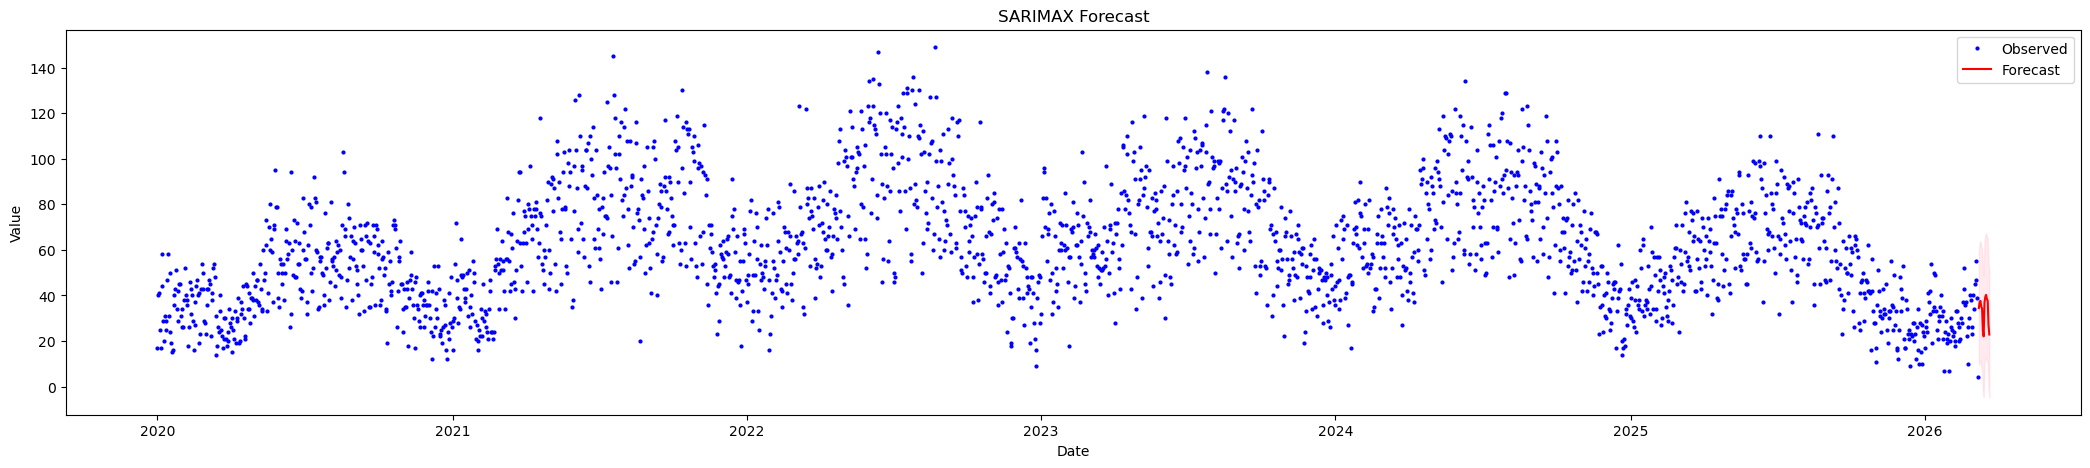

In [19]:
observed_dates = rs['ds']
observed_values = rs['y']
forecast_dates = pd.date_range(start=observed_dates.iloc[-1] + pd.Timedelta(days=1), periods=forecast_steps)

plt.figure(figsize=(26, 5))

plt.plot(observed_dates, observed_values, label='Observed', color='blue', marker='o', linestyle='None', markersize=2)
plt.plot(forecast_dates, forecast_mean.values, label='Forecast', color='red')
plt.fill_between(forecast_dates,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 color='pink', alpha=0.3)

plt.xlabel("Date")
plt.ylabel("Value")
plt.title("SARIMAX Forecast")
plt.legend()
plt.show()

In [20]:
# forecast for the next 14 days
forecast_mean.index = forecast_dates

forecast_mean

2026-03-09    34.471519
2026-03-10    37.258301
2026-03-11    37.645261
2026-03-12    35.155439
2026-03-13    34.351345
2026-03-14    24.507142
2026-03-15    22.042260
2026-03-16    36.887859
2026-03-17    39.343762
2026-03-18    40.284131
2026-03-19    38.533813
2026-03-20    37.722349
2026-03-21    26.996255
2026-03-22    22.836746
Freq: D, Name: predicted_mean, dtype: float64

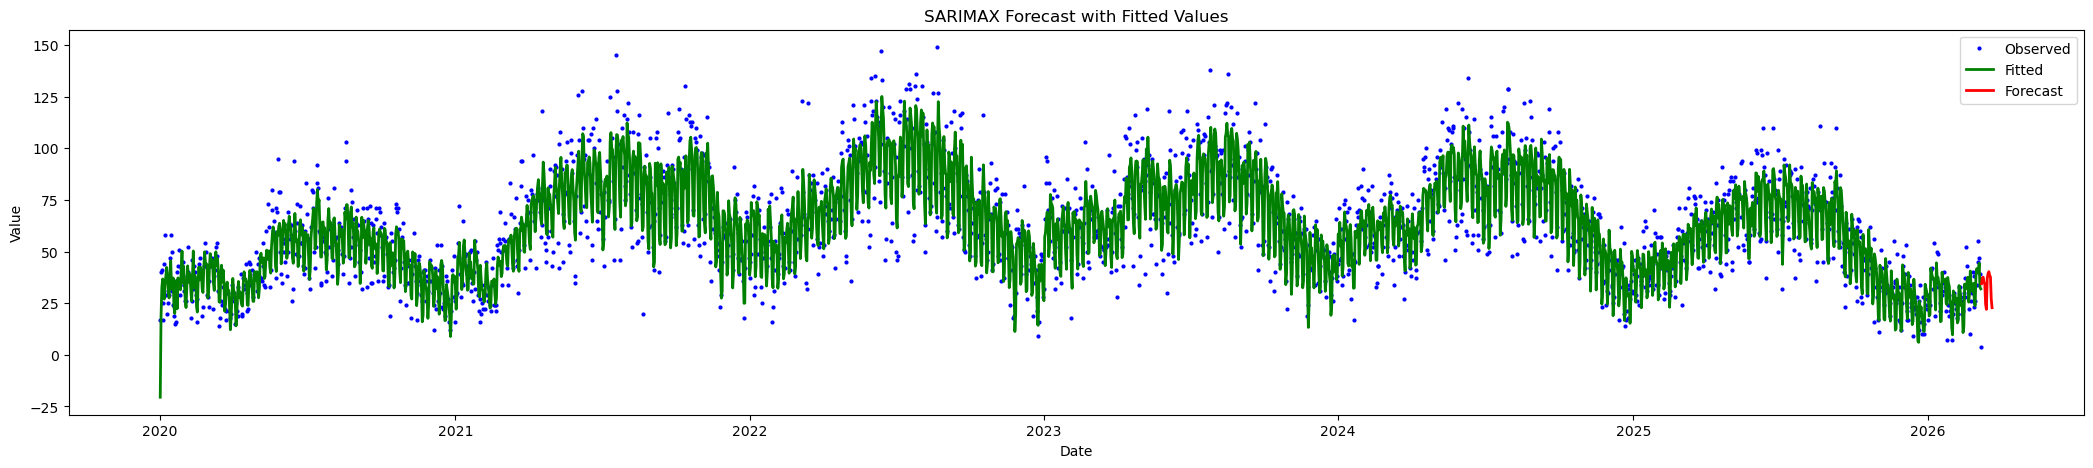

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Here are the in-sample predictions
fitted_values = fitted_model.get_prediction(start=0, end=len(rs)-1, dynamic=False, exog=exog_train)
fitted_mean = pd.Series(fitted_values.predicted_mean.values, index=observed_dates)

plt.figure(figsize=(26, 5))

plt.plot(observed_dates, observed_values, label='Observed', color='blue', marker='o', linestyle='None', markersize=2)

plt.plot(observed_dates, fitted_mean, label='Fitted', color='green', linewidth=2)

plt.plot(forecast_dates, forecast_mean, label='Forecast', color='red', linewidth=2)

# we can also add a confidence interval if we'd like
# plt.fill_between(forecast_dates,
#                  forecast_ci.iloc[:, 0],
#                  forecast_ci.iloc[:, 1],
#                  color='pink', alpha=0.3)

plt.xlabel("Date")
plt.ylabel("Value")
plt.title("SARIMAX Forecast with Fitted Values")
plt.legend()
plt.show()